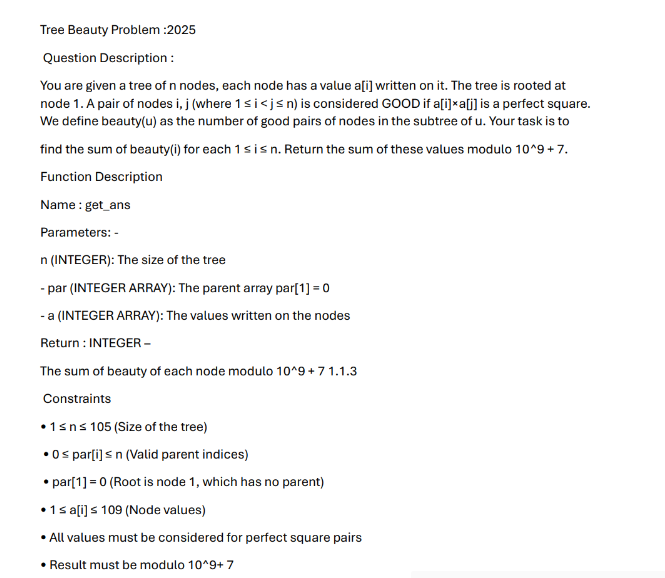
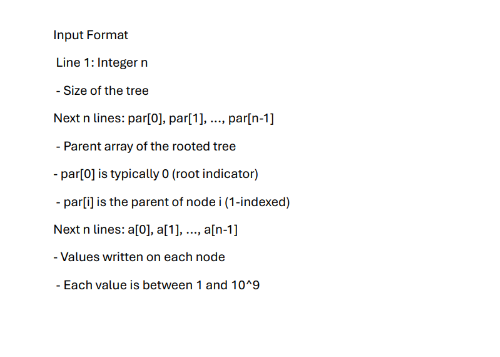
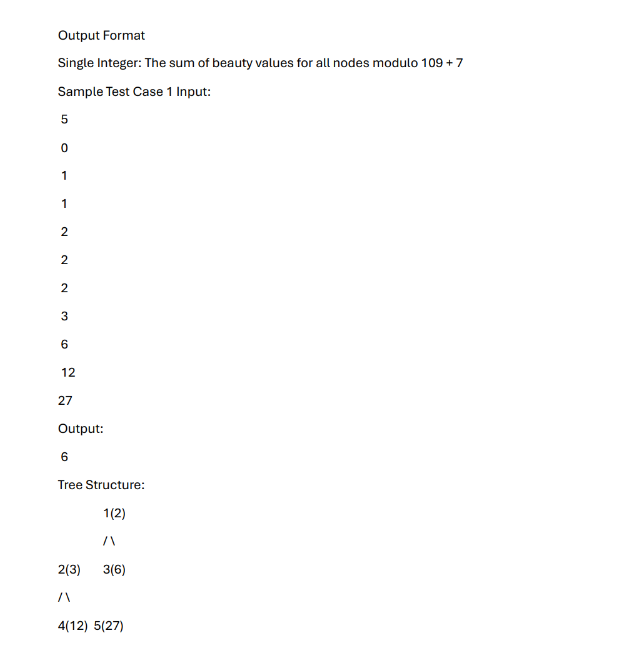
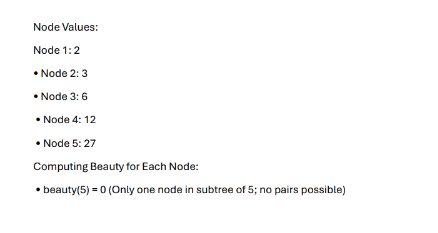
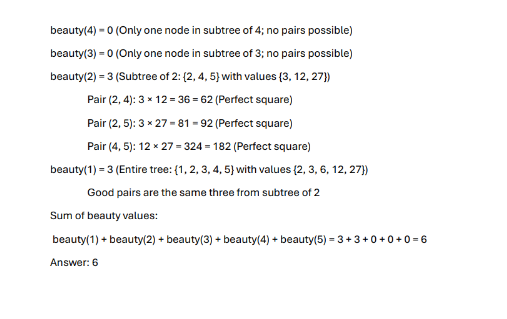

In [2]:
def get_ans(n, par, a):
    import sys
    sys.setrecursionlimit(10**7)
    MOD = 10**9 + 7

    # -----------------------------
    # Step 1: Build tree
    # -----------------------------
    tree = [[] for _ in range(n + 1)]
    for i in range(2, n + 1):
        tree[par[i]].append(i)

    # -----------------------------
    # Step 2: Square-free function
    # -----------------------------
    def square_free(x):
        res = 1
        d = 2
        while d * d <= x:
            cnt = 0
            while x % d == 0:
                x //= d
                cnt += 1
            if cnt % 2 == 1:
                res *= d
            d += 1
        if x > 1:
            res *= x
        return res

    sf = [0] * (n + 1)
    for i in range(1, n + 1):
        sf[i] = square_free(a[i])

    # -----------------------------
    # Step 3: DSU on Tree
    # -----------------------------
    beauty_sum = 0

    def dfs(u):
        nonlocal beauty_sum

        freq = {}
        pairs = 0

        for v in tree[u]:
            child_freq, child_pairs = dfs(v)

            # Always merge smaller into larger
            if len(child_freq) > len(freq):
                freq, child_freq = child_freq, freq
                pairs += child_pairs
            else:
                pairs += child_pairs

            for k, c in child_freq.items():
                pairs += freq.get(k, 0) * c
                freq[k] = freq.get(k, 0) + c

        # Add current node
        val = sf[u]
        pairs += freq.get(val, 0)
        freq[val] = freq.get(val, 0) + 1

        beauty_sum = (beauty_sum + pairs) % MOD
        return freq, pairs

    dfs(1)
    return beauty_sum % MOD


In [3]:
n = 5
par = [0, 0, 1, 1, 2, 2]     # par[1] = 0
a   = [0, 2, 3, 6, 12, 27]  # a[1] = 2, a[2] = 3, ...

print(get_ans(n, par, a))  # Output: 6


6
